# Parte 5 — Bonus: LoRA sobre BERTweet
### Workshop: Clasificación de Emociones en Twitter

BERTweet tiene ~110M parámetros — el doble que DistilBERT. LoRA permite adaptarlo con una fracción mínima de los parámetros.

BERTweet usa la arquitectura de BERT, cuyas proyecciones de atención tienen nombres distintos a DistilBERT:

| Modelo | Proyecciones |
|---|---|
| DistilBERT | `q_lin`, `k_lin`, `v_lin`, `out_lin` |
| BERTweet / BERT | `query`, `key`, `value`, `dense` |

**Prerequisito:** haber ejecutado `part-1-data.ipynb` y `part-2-pipeline.ipynb`

In [1]:
!pip install peft -q
%run /teamspace/studios/this_studio/SI7011-DeepLearning/Lecture06/notebooks/excercise/tweeteval-part-2-pipeline.ipynb

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/nbformat/__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})
compute_metrics OK
make_tokenized_dataset OK
full_evaluation OK
plot_training_curves OK
make_trainer OK

Pipeline lista. Puedes continuar con part-3-distilbert.ipynb


In [2]:
from peft import LoraConfig, get_peft_model, TaskType

MODEL_CHECKPOINT = "vinai/bertweet-base"
HF_REPO          = "jezapataf/tweeteval-emotion-bertweet-lora"  # <-- cambia esto
LR_LORA          = 2e-4   # más alto que full FT — pocos parámetros entrenables

## Dataset tokenizado

Reutilizamos el tokenizador de BERTweet del experimento anterior.

In [3]:
from transformers import AutoTokenizer

tok_bertweet = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, normalization=True)
ds_bertweet  = make_tokenized_dataset(tok_bertweet)
print(ds_bertweet)

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 374
    })
})


## Inspección de módulos

Antes de aplicar LoRA, inspeccionamos los nombres de las capas lineales de BERTweet.

In [4]:
from transformers import AutoModelForSequenceClassification

base_bt = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT, num_labels=NUM_LABELS,
    id2label=ID2LABEL, label2id=LABEL2ID)

print("Módulos lineales de BERTweet:")
for name, module in base_bt.named_modules():
    if isinstance(module, torch.nn.Linear):
        print(f"  {name}  [{module.in_features} → {module.out_features}]")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Módulos lineales de BERTweet:
  roberta.encoder.layer.0.attention.self.query  [768 → 768]
  roberta.encoder.layer.0.attention.self.key  [768 → 768]
  roberta.encoder.layer.0.attention.self.value  [768 → 768]
  roberta.encoder.layer.0.attention.output.dense  [768 → 768]
  roberta.encoder.layer.0.intermediate.dense  [768 → 3072]
  roberta.encoder.layer.0.output.dense  [3072 → 768]
  roberta.encoder.layer.1.attention.self.query  [768 → 768]
  roberta.encoder.layer.1.attention.self.key  [768 → 768]
  roberta.encoder.layer.1.attention.self.value  [768 → 768]
  roberta.encoder.layer.1.attention.output.dense  [768 → 768]
  roberta.encoder.layer.1.intermediate.dense  [768 → 3072]
  roberta.encoder.layer.1.output.dense  [3072 → 768]
  roberta.encoder.layer.2.attention.self.query  [768 → 768]
  roberta.encoder.layer.2.attention.self.key  [768 → 768]
  roberta.encoder.layer.2.attention.self.value  [768 → 768]
  roberta.encoder.layer.2.attention.output.dense  [768 → 768]
  roberta.encoder.layer.2.

### 📝 TODO 5.1 — Configurar y aplicar LoRA a BERTweet

In [5]:
# TODO 5.1 ── LoRA sobre BERTweet
# ─────────────────────────────────────────────────────────────────────────────
# 1. Define un LoraConfig con:
#    - task_type=TaskType.SEQ_CLS
#    - r=8, lora_alpha=16, lora_dropout=0.1
#    - target_modules: proyecciones query y value de BERTweet
#      (observa los nombres en la celda de inspección de arriba)
#    - modules_to_save: la cabeza clasificadora
#
# 2. Aplica LoRA con get_peft_model() e imprime los parámetros entrenables

# YOUR CODE HERE
from peft import LoraConfig, TaskType, get_peft_model

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"],
    modules_to_save=["classifier"]
)

model_bertweet_lora = get_peft_model(
    base_bt,
    lora_config
)

model_bertweet_lora.print_trainable_parameters()

trainable params: 888,580 || all params: 135,791,624 || trainable%: 0.6544


### 📝 TODO 5.2 — Entrenar BERTweet-LoRA

Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,0.956430,0.876024,0.517298,0.689840
2,0.589203,0.677826,0.667104,0.743316
3,0.533948,0.553604,0.711425,0.778075
4,0.525960,0.539052,0.713328,0.778075
5,0.463892,0.544790,0.715372,0.780749


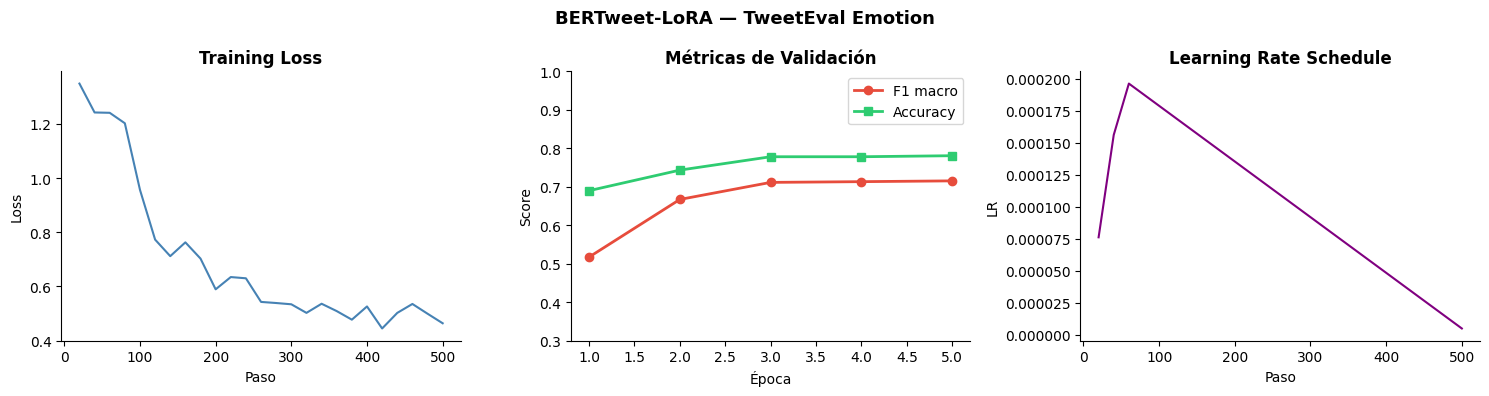


  Test — BERTweet-LoRA
              precision    recall  f1-score   support

       anger     0.8599    0.8907    0.8750       558
         joy     0.8440    0.8464    0.8452       358
    optimism     0.7579    0.5854    0.6606       123
     sadness     0.7943    0.8089    0.8016       382

    accuracy                         0.8311      1421
   macro avg     0.8140    0.7828    0.7956      1421
weighted avg     0.8294    0.8311    0.8292      1421



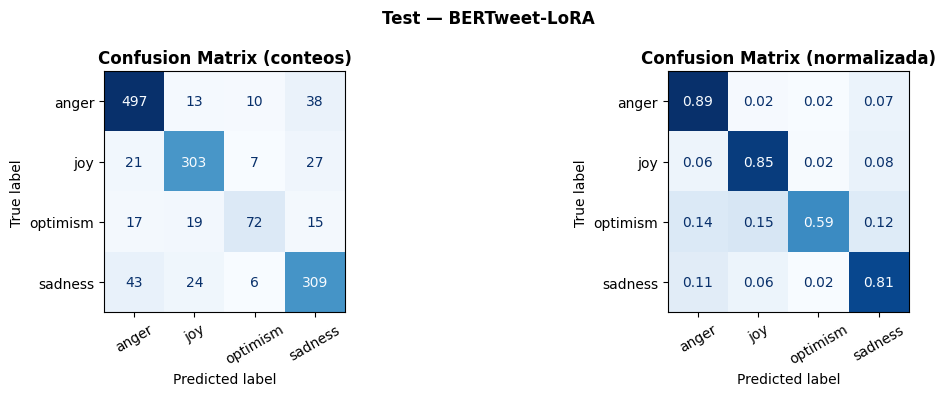

{'test_loss': 0.49952057003974915,
 'test_f1_macro': 0.795573790866972,
 'test_accuracy': 0.8311048557353976,
 'test_runtime': 0.9627,
 'test_samples_per_second': 1475.99,
 'test_steps_per_second': 46.741}

In [6]:
# TODO 5.2 ── Entrenar BERTweet-LoRA
# ─────────────────────────────────────────────────────────────────────────────
# Usa make_trainer() con lr=LR_LORA y output_dir="./checkpoints/bertweet-lora"
# Dataset: ds_bertweet (ya está tokenizado)
# Guarda los resultados en metrics_bertweet_lora y el trainer en trainer_lora

# YOUR CODE HERE
trainer_lora = make_trainer(
    model_bertweet_lora,
    tok_bertweet,
    ds_bertweet,
    output_dir="./checkpoints/bertweet-lora",
    lr=LR_LORA
)

trainer_lora.train()

plot_training_curves(
    trainer_lora,
    title="BERTweet-LoRA — TweetEval Emotion"
)

metrics_bertweet_lora = full_evaluation(
    trainer_lora,
    ds_bertweet["test"],
    model_name="BERTweet-LoRA"
)

metrics_bertweet_lora

## Push to Hub

Para subir el modelo LoRA al Hub necesitamos fusionarlo primero (`merge_and_unload`), que aplica $W' = W + BA$ y devuelve un modelo estándar sin overhead PEFT.

In [7]:
merged = model_bertweet_lora.merge_and_unload()
merged.push_to_hub(HF_REPO, commit_message="BERTweet LoRA r=8 — merged")
tok_bertweet.push_to_hub(HF_REPO)
print(f"Modelo publicado en: https://huggingface.co/{HF_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Modelo publicado en: https://huggingface.co/jezapataf/tweeteval-emotion-bertweet-lora
